In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

conn = sqlite3.connect("C:/Users/DS/Documents/cricketsheet/cricket.db")

def run_query(query):
    return pd.read_sql(query, conn)

print("✅ Connected to DB")

✅ Connected to DB


In [7]:
#SQL Query
# 1) Top ODI Batsmen
q1 = """SELECT batsman, SUM(runs) AS total_runs FROM odi_matches GROUP BY batsman ORDER BY total_runs DESC LIMIT 10; """
df1 = run_query(q1)
df1

,batsman,total_runs
0,V Kohli,4588
1,RG Sharma,4106
2,LRPL Taylor,2819
3,JE Root,2788
4,S Dhawan,2610
5,Babar Azam,2576
6,SD Hope,2552
7,KS Williamson,2429
8,JJ Roy,2345
9,JM Bairstow,2320


In [9]:
#Top T20 batsman 
q2 = """SELECT batsman, SUM(runs) AS total_runs FROM t20_matches GROUP BY batsman ORDER BY total_runs DESC LIMIT 10;"""
df2 = run_query(q2)
df2

,batsman,total_runs
0,RG Sharma,1496
1,KL Rahul,1377
2,Babar Azam,1347
3,BL Mooney,1312
4,C Munro,1229
5,SFM Devine,1186
6,AJ Healy,1160
7,S Mandhana,1145
8,SW Bates,1116
9,V Kohli,1103


In [10]:
#Top Testmatches batsmen
q3 = """SELECT batsman, SUM(runs) AS total_runs FROM test_matches GROUP BY batsman ORDER BY total_runs DESC LIMIT 10; """
df3 = run_query(q3)
df3

,batsman,total_runs
0,JE Root,9938
1,SPD Smith,6664
2,V Kohli,6236
3,BA Stokes,5787
4,KS Williamson,5340
5,FDM Karunaratne,5193
6,UT Khawaja,5084
7,TWM Latham,4961
8,CA Pujara,4740
9,M Labuschagne,4694


<Axes: title={'center': 'Top Bowlers Overall'}, xlabel='bowler'>

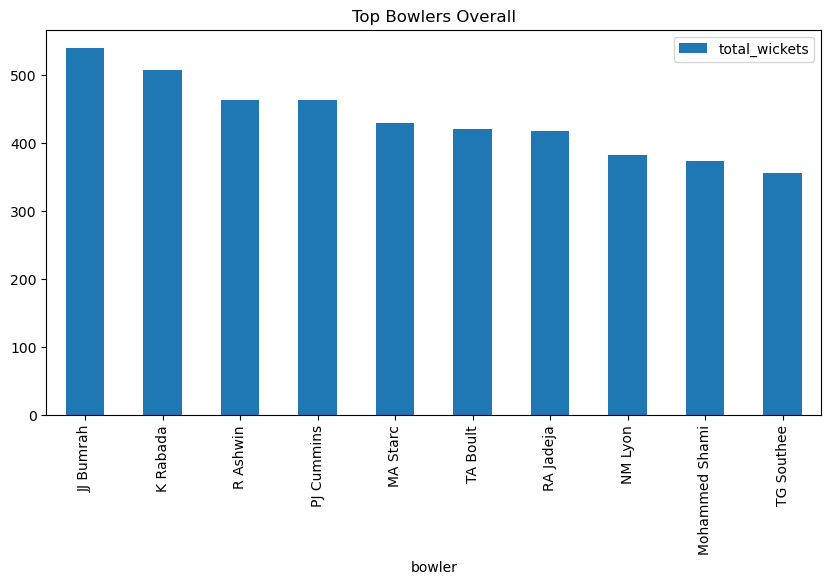

In [40]:
# Top bowler form all the matches
q4 = """
SELECT bowler,
       SUM(CASE WHEN format = 'odi' THEN wickets ELSE 0 END) AS odi_wickets,
       SUM(CASE WHEN format = 't20' THEN wickets ELSE 0 END) AS t20_wickets,
       SUM(CASE WHEN format = 'test' THEN wickets ELSE 0 END) AS test_wickets,
       SUM(CASE WHEN format = 'ipl' THEN wickets ELSE 0 END) AS ipl_wickets,
       SUM(wickets) AS total_wickets
FROM (
    SELECT bowler, is_wicket AS wickets, 'odi' AS format FROM odi_matches
    UNION ALL
    SELECT bowler, is_wicket, 't20' FROM t20_matches
    UNION ALL
    SELECT bowler, is_wicket, 'test' FROM test_matches
    UNION ALL
    SELECT bowler, is_wicket, 'ipl' FROM ipl_matches
)
GROUP BY bowler
ORDER BY total_wickets DESC
LIMIT 10;
"""

df = run_query(q4)
df

df.plot(kind="bar", x="bowler", y="total_wickets", title="Top Bowlers Overall")

In [46]:
#ALl Rounders of all the matches 

q5 = """
SELECT player,
       SUM(runs) AS total_runs,
       SUM(wickets) AS total_wickets
FROM (
    SELECT batsman AS player, runs, 0 AS wickets FROM odi_matches
    UNION ALL
    SELECT batsman, runs, 0 FROM t20_matches
    UNION ALL
    SELECT batsman, runs, 0 FROM test_matches
    UNION ALL
    SELECT batsman, runs, 0 FROM ipl_matches

    UNION ALL

    SELECT bowler AS player, 0, is_wicket FROM odi_matches
    UNION ALL
    SELECT bowler, 0, is_wicket FROM t20_matches
    UNION ALL
    SELECT bowler, 0, is_wicket FROM test_matches
    UNION ALL
    SELECT bowler, 0, is_wicket FROM ipl_matches
)
GROUP BY player
ORDER BY total_runs DESC, total_wickets DESC
LIMIT 15;
"""
df5 = run_query(q5)
df5

,player,total_runs,total_wickets
0,V Kohli,15627,2
1,JE Root,13029,79
2,RG Sharma,11672,0
3,KS Williamson,10455,14
4,KL Rahul,10119,0
5,DA Warner,9729,0
6,SPD Smith,9668,5
7,BA Stokes,8683,258
8,JM Bairstow,8491,0
9,Babar Azam,8289,2


In [45]:
# economy rate

q6 = """
SELECT bowler, SUM(total_runs)*1.0/COUNT(*) AS economy
FROM t20_matches
GROUP BY bowler
ORDER BY economy ASC
LIMIT 10;
"""
df6 = run_query(q6)
df6

,bowler,economy
0,C Kauripeke,0.000000
1,G Obukor,0.083333
2,JD Campbell,0.166667
3,S Saenya,0.166667
4,S Namusha,0.245614
5,AC Mushangwe,0.289256
6,M Anyigo,0.312500
7,L Phiri,0.315789
8,WJR Robertson,0.333333
9,T Granger,0.337349


In [48]:
#ODI team Run 

q7 = """
SELECT team, SUM(total_runs) AS runs
FROM odi_matches
GROUP BY team
ORDER BY runs DESC;
"""
df7 = run_query(q7)
df7

,team,runs
0,India,29618
1,England,25842
2,Australia,23798
3,New Zealand,23022
4,South Africa,20943
5,Pakistan,19354
6,Sri Lanka,19306
7,West Indies,17747
8,Bangladesh,14526
9,Zimbabwe,8451


In [49]:
# Total t20 matches 
q8 = "SELECT COUNT(DISTINCT match_id) AS total_matches FROM t20_matches;"
run_query(q8)

,total_matches
0,500


In [50]:
# Average runs per over in t20
q9 = """
SELECT over, AVG(total_runs) AS avg_runs
FROM t20_matches
GROUP BY over;
"""
df9 = run_query(q9)
df9

,over,avg_runs
0,0,0.899256
1,1,1.063826
2,2,1.123594
3,3,1.128367
4,4,1.118287
5,5,1.151471
6,6,0.960278
7,7,1.035082
8,8,1.037292
9,9,1.103931


In [27]:
# Extra overs in ODI matches 
q10 = "SELECT SUM(extras) AS total_extras FROM odi_matches;"
run_query(q10)

,total_extras
0,11471


In [51]:
# Dot ball percentage in t20 Matches 
q11 = """
SELECT batsman,
SUM(CASE WHEN runs=0 THEN 1 ELSE 0 END)*100.0/COUNT(*) AS dot_percentage
FROM t20_matches
GROUP BY batsman;
"""
run_query(q11)

,batsman,dot_percentage
0,A Aitken,66.666667
1,A Balbirnie,31.791908
2,A Bierwisch,77.358491
3,A Bohara,100.000000
4,A Bulow,53.846154
...,...,...
1343,Zhang Xiangxue,50.000000
1344,Zheng Lili,75.000000
1345,Zinaida Jeremiah,69.565217
1346,Zishan Shah,41.379310


In [52]:
#players and bowlers 
q12 = """
SELECT batsman, bowler, SUM(runs) AS runs
FROM t20_matches
GROUP BY batsman, bowler
ORDER BY runs DESC;
"""
run_query(q12)

,batsman,bowler,runs
0,DJ Malan,IS Sodhi,95
1,BL Mooney,KH Brunt,92
2,BL Mooney,A Shrubsole,79
3,RG Sharma,MJ Santner,78
4,GJ Maxwell,KH Pandya,72
...,...,...,...
17434,Zishan Shah,EJB Miles,0
17435,Zumika Azmi,ER Oza,0
17436,Zumika Azmi,P Vastrakar,0
17437,Zumika Azmi,RS Gayakwad,0


In [53]:
# t2o best matches perfomance 

q13 = """
SELECT batsman, match_id, SUM(runs) AS total_runs
FROM t20_matches
GROUP BY batsman, match_id
ORDER BY total_runs DESC
LIMIT 10;
"""
run_query(q13)

,batsman,match_id,total_runs
0,AJ Finch,1142915,172
1,AJ Healy,1183512,148
2,MM Lanning,1168026,133
3,SL Kalis,1190606,126
4,E Lewis,1098211,125
5,DN Wyatt,1131237,124
6,SW Bates,1126720,124
7,RG Sharma,1122730,118
8,BL Mooney,1086069,117
9,Shaiman Anwar,1089203,117


In [54]:
# all format players 

q14 = """
SELECT batsman, SUM(runs) AS total_runs
FROM (
SELECT batsman, runs FROM odi_matches
UNION ALL
SELECT batsman, runs FROM t20_matches
UNION ALL
SELECT batsman, runs FROM test_matches
)
GROUP BY batsman
ORDER BY total_runs DESC
LIMIT 10;
"""
run_query(q14)

,batsman,total_runs
0,JE Root,13019
1,V Kohli,11927
2,RG Sharma,9007
3,KS Williamson,8478
4,SPD Smith,8414
5,Babar Azam,8289
6,BA Stokes,7748
7,JM Bairstow,6943
8,TWM Latham,6766
9,DA Warner,6536


In [58]:
# Total number of matches and the trophies win in IPL 

q15 = """
WITH final_matches AS (
    SELECT match_id, team
    FROM ipl_matches
    WHERE match_id IN (
        SELECT MAX(match_id)
        FROM ipl_matches
        GROUP BY substr(match_id, 1, 4)   -- assuming year in match_id
    )
),
winners AS (
    SELECT team AS winner
    FROM final_matches
)
SELECT winner AS team, COUNT(*) AS trophies
FROM winners
GROUP BY winner
ORDER BY trophies DESC;
"""

df15 = run_query(q15)
df15

,team,trophies
0,Mumbai Indians,591
1,Chennai Super Kings,581
2,Gujarat Titans,480
3,Kolkata Knight Riders,379
4,Royal Challengers Bangalore,378
5,Sunrisers Hyderabad,252
6,Punjab Kings,219
7,Rising Pune Supergiant,123
8,Delhi Capitals,123
9,Lucknow Super Giants,121


In [56]:
# Extra wicket per over

q16 = """
SELECT over, SUM(is_wicket) AS wickets
FROM t20_matches
GROUP BY over;
"""
df16 = run_query(q16)
df16

,over,wickets
0,0,218
1,1,243
2,2,279
3,3,286
4,4,300
5,5,265
6,6,222
7,7,249
8,8,239
9,9,248


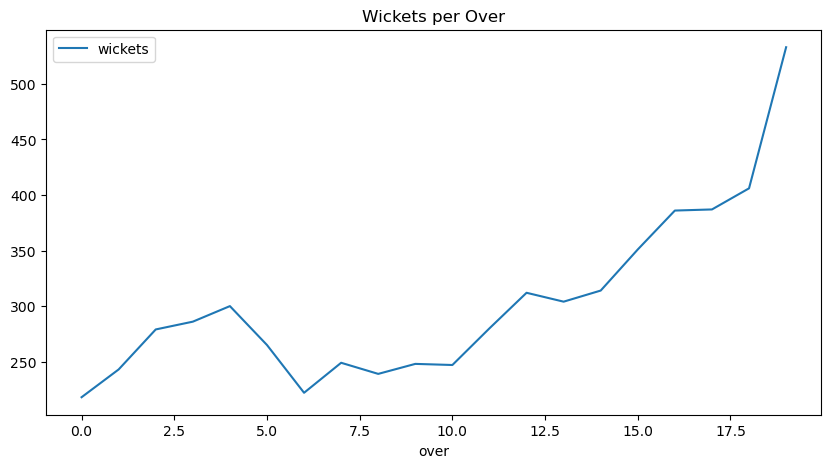

In [57]:
df16.plot(x="over", y="wickets", title="Wickets per Over")
plt.show()

<Axes: title={'center': 'IPL Trophies by Team'}, xlabel='team'>

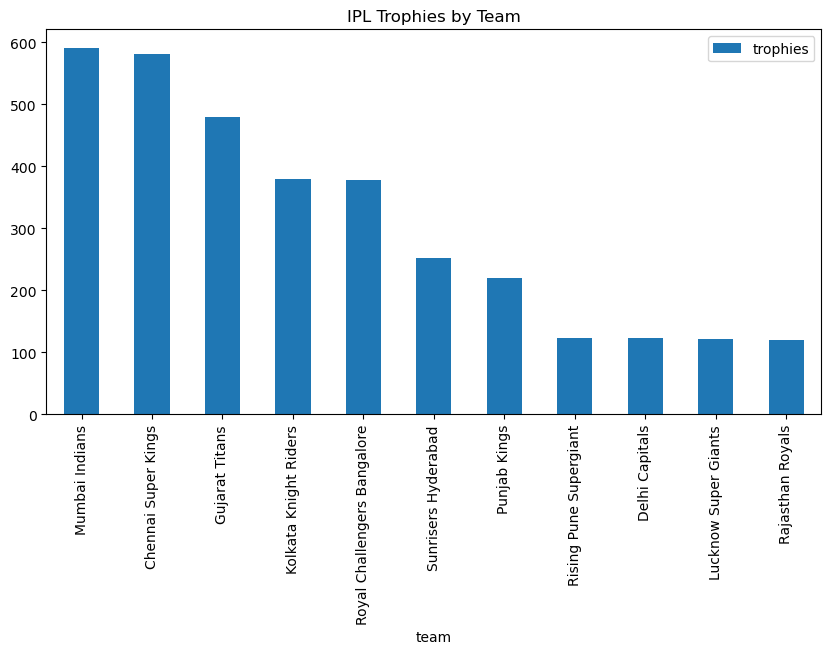

In [59]:
#IPl trophies 

df15.plot(kind="bar", x="team", y="trophies", title="IPL Trophies by Team")

In [60]:
# total number of century in all matches 

q17 = """
SELECT COUNT(*) AS total_centuries
FROM (
    SELECT batsman, match_id, SUM(runs) AS total_runs
    FROM (
        SELECT batsman, match_id, runs FROM odi_matches
        UNION ALL
        SELECT batsman, match_id, runs FROM t20_matches
        UNION ALL
        SELECT batsman, match_id, runs FROM test_matches
        UNION ALL
        SELECT batsman, match_id, runs FROM ipl_matches
    )
    GROUP BY batsman, match_id
    HAVING total_runs >= 100
);
"""

df17 = run_query(q17)
df17

,total_centuries
0,1693


In [63]:
# fastest century 
q18 = """
WITH all_data AS (
    SELECT batsman, match_id, runs
    FROM odi_matches
    UNION ALL
    SELECT batsman, match_id, runs FROM t20_matches
    UNION ALL
    SELECT batsman, match_id, runs FROM test_matches
    UNION ALL
    SELECT batsman, match_id, runs FROM ipl_matches
),

player_innings AS (
    SELECT batsman,
           match_id,
           SUM(runs) AS total_runs,
           COUNT(*) AS balls_faced
    FROM all_data
    GROUP BY batsman, match_id
    HAVING total_runs >= 100
)

SELECT batsman,
       match_id,
       total_runs,
       balls_faced
FROM player_innings
ORDER BY balls_faced ASC
LIMIT 10;
"""

df18 = run_query(q18)
df18

,batsman,match_id,total_runs,balls_faced
0,DA Miller,1075508,101,38
1,WG Jacks,1426283,100,42
2,RG Sharma,1122730,118,44
3,TM Head,1426268,102,45
4,C Green,1359543,100,47
5,JM Bairstow,1426280,108,48
6,SA Yadav,1359531,103,49
7,E Lewis,1041615,100,50
8,H Kaur,1150533,103,51
9,H Klaasen,1359539,104,52


<Axes: title={'center': 'Fastest Centuries'}, xlabel='batsman'>

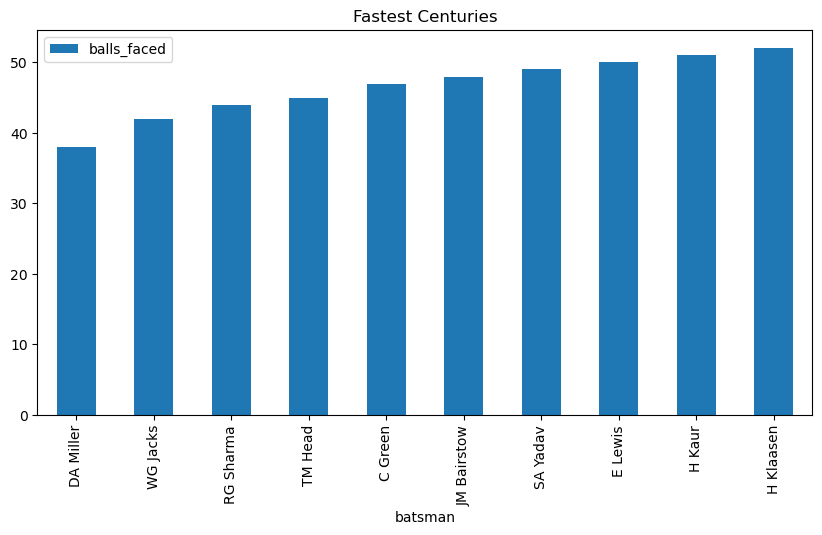

In [64]:
df18.plot(kind="bar", x="batsman", y="balls_faced", title="Fastest Centuries")

In [66]:
#Matches with the narrowest margin of victory.
q19 = """
WITH match_totals AS (
    SELECT match_id, team, SUM(total_runs) AS team_runs
    FROM t20_matches
    GROUP BY match_id, team
),

match_compare AS (
    SELECT m1.match_id,
           m1.team AS team1,
           m2.team AS team2,
           m1.team_runs AS team1_runs,
           m2.team_runs AS team2_runs,
           ABS(m1.team_runs - m2.team_runs) AS margin
    FROM match_totals m1
    JOIN match_totals m2
    ON m1.match_id = m2.match_id AND m1.team < m2.team
)

SELECT *
FROM match_compare
ORDER BY margin ASC
LIMIT 10;
"""

df19 = run_query(q19)
df19

,match_id,team1,team2,team1_runs,team2_runs,margin
0,1142504,Ireland,Scotland,185,185,0
1,1031431,England,South Africa,143,142,1
2,1034825,England,India,148,147,1
3,1041615,India,West Indies,244,245,1
4,1050217,Pakistan,West Indies,116,115,1
5,1072318,Australia,England,138,137,1
6,1074968,Oman,Scotland,133,134,1
7,1085495,Pakistan,West Indies,137,138,1
8,1115807,New Zealand,Pakistan,106,105,1
9,1117822,ICC World XI,Pakistan,175,174,1


<Axes: title={'center': 'Closest Matches (Run Margin)'}, xlabel='match_id'>

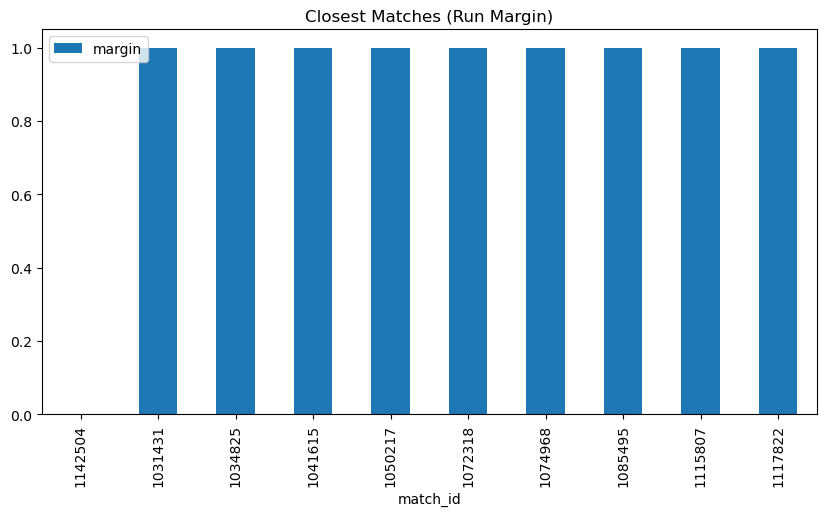

In [67]:
df19.plot(kind="bar", x="match_id", y="margin", title="Closest Matches (Run Margin)")

In [68]:
# Last over finishes 

q20 = """
WITH match_totals AS (
    SELECT match_id, team, SUM(total_runs) AS team_runs
    FROM t20_matches
    GROUP BY match_id, team
),

last_over_runs AS (
    SELECT match_id, team, SUM(total_runs) AS last_over_runs
    FROM t20_matches
    WHERE over = 19   -- final over in T20 (0-indexed)
    GROUP BY match_id, team
),

match_compare AS (
    SELECT m1.match_id,
           m1.team AS team1,
           m2.team AS team2,
           m1.team_runs AS team1_runs,
           m2.team_runs AS team2_runs,
           ABS(m1.team_runs - m2.team_runs) AS margin
    FROM match_totals m1
    JOIN match_totals m2
    ON m1.match_id = m2.match_id AND m1.team < m2.team
)

SELECT mc.match_id,
       mc.team1,
       mc.team2,
       mc.team1_runs,
       mc.team2_runs,
       mc.margin,
       lo.last_over_runs
FROM match_compare mc
JOIN last_over_runs lo
ON mc.match_id = lo.match_id
WHERE mc.margin <= 10   -- close match
ORDER BY mc.margin ASC
LIMIT 10;
"""

df20 = run_query(q20)
df20

,match_id,team1,team2,team1_runs,team2_runs,margin,last_over_runs
0,1142504,Ireland,Scotland,185,185,0,6
1,1142504,Ireland,Scotland,185,185,0,6
2,1031431,England,South Africa,143,142,1,11
3,1034825,England,India,148,147,1,12
4,1041615,India,West Indies,244,245,1,6
5,1041615,India,West Indies,244,245,1,10
6,1050217,Pakistan,West Indies,116,115,1,3
7,1072318,Australia,England,138,137,1,8
8,1074968,Oman,Scotland,133,134,1,5
9,1085495,Pakistan,West Indies,137,138,1,5


<Axes: title={'center': 'Last Over Finishes'}, xlabel='match_id'>

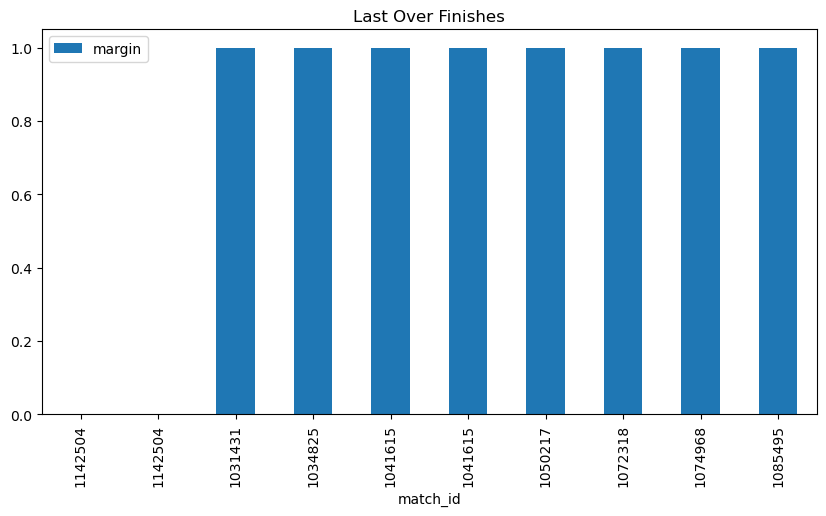

In [69]:
df20.plot(kind="bar", x="match_id", y="margin", title="Last Over Finishes")